# run dsb nomralization in moun for ADT denoise and normalization
- related to Fig S8 C-G
- Data from Thomson et al. https://www.nature.com/articles/s41590-023-01641-8
- TEAseq data in sorted T cells from healthy children and older adult
- rerun protein normalization based on DSB method (https://www.nature.com/articles/s41467-022-29356-8) in this dataset 

In [1]:
import glob
import os

import anndata as ad
import h5py
import hisepy as hp
import mudata as md
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as scs
import seaborn as sns
from mudata import MuData
from muon import prot as pt

/home/workspace/environment/scanpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# download data
hp.cache_files(["6c3854ca-c967-4760-a60a-423e9a299288"])

['/home/workspace/input/569004694/PedvsSenior/6c3854ca-c967-4760-a60a-423e9a299288/AIFI-PSP-2025-04-23T20:11:52.431261185Z/B069_B076_raw_filt_10x_h5s.zip']

In [208]:
hp.cache_files(
    [
        "accae0f2-d49e-4ef9-8aab-eb389e76839d",
        "8a34dd08-cbbc-4eef-96f9-495c307509b5",
        "5cc7d154-dc47-49f1-af64-bdbaa8ec4c09",
        "45ad8139-68b1-4872-8e32-d1e1bb43b0a5",
        "67d38ab6-cf2c-4ea2-a344-74f3450babb9",
        "202c7c0d-9a85-4495-b15c-d5e55200feda",
        "769c6582-5375-461e-be24-d284a16a2fdb",
        "83225218-1dfe-46be-9245-89d35b3d9a38",
        "d1ea0411-274c-47e3-86a1-d7965a6e8495",
        "3df725cf-83b0-4c6d-98ef-c6f3a27b5287",
        "0374954f-b0df-4707-9d8c-4d049cd0e935",
        "bf8c654a-afdd-40da-a70d-629eb2413277",
        "98ddbed6-8385-43f9-8cd1-17c0e451d63f",
        "4b1267ff-0e3c-413d-bc6e-24f6313ab0c3",
        "86c3b6d7-7e9b-417e-876f-41e3dfdf3cc2",
        "43951343-50bb-4f40-be3b-6265f372c1db",
        "b7d01f2a-50aa-4b52-a45d-e7a1cb54014d",
        "35a51c40-36a8-465d-ac9e-b87245669b35",
        "7db7ee2c-a697-4575-a5f2-f1fca7da39b4",
        "c6dd6b9a-c9d3-46f1-a196-f6d24440112b",
        "cadc87f4-06fc-4388-a930-d1fca4a5ebe8",
        "44751b1f-90e3-4d10-a59a-4df52810d3e2",
        "3cff66be-a5ef-4b38-9a23-f069e3aaba31",
        "0f298c69-6871-4f1c-a1ff-8d8e342e7d2c",
        "6fba74f5-20c9-4d83-99bd-a5b02c3d34ae",
        "d398728d-0739-442d-bc58-25709c3a4d26",
        "ccfa20a0-4e60-4082-9004-a6b52e6d1f31",
        "306b63fe-aabc-4055-bec0-41baca348efc",
        "682fc78f-a022-40c0-b9a5-8056d0df7af9",
        "e44f3933-9c7e-412c-bf47-bc8077c2edf4",
        "6b9a022a-84ca-4803-be65-b5843d939322",
        "dab1486f-8db0-4610-96fc-4cd70146e6f4",
    ]
)

['/home/workspace/input/569004694/PedvsSenior/accae0f2-d49e-4ef9-8aab-eb389e76839d/automated/tea-tenx/2024-06-22T09:01:33.87809677Z/Version-1/e192a1ae-f38c-4019-9b37-27c41d642fb4/B065-RP1C1W3/outs/filtered_feature_bc_matrix.h5',
 '/home/workspace/input/569004694/PedvsSenior/8a34dd08-cbbc-4eef-96f9-495c307509b5/automated/tea-tenx/2024-06-22T09:01:33.87809677Z/Version-1/e192a1ae-f38c-4019-9b37-27c41d642fb4/B065-RP1C1W5/outs/filtered_feature_bc_matrix.h5',
 '/home/workspace/input/569004694/PedvsSenior/5cc7d154-dc47-49f1-af64-bdbaa8ec4c09/automated/tea-tenx/2024-06-22T09:01:33.87809677Z/Version-1/e192a1ae-f38c-4019-9b37-27c41d642fb4/B065-RP1C1W7/outs/filtered_feature_bc_matrix.h5',
 '/home/workspace/input/569004694/PedvsSenior/45ad8139-68b1-4872-8e32-d1e1bb43b0a5/automated/tea-tenx/2024-06-22T09:01:33.87809677Z/Version-1/e192a1ae-f38c-4019-9b37-27c41d642fb4/B065-RP1C1W4/outs/filtered_feature_bc_matrix.h5',
 '/home/workspace/input/569004694/PedvsSenior/67d38ab6-cf2c-4ea2-a344-74f3450babb9/a

In [6]:
import zipfile

# Path to the zip file
zip_path = "/home/workspace/input/569004694/PedvsSenior/6c3854ca-c967-4760-a60a-423e9a299288/AIFI-PSP-2025-04-23T20:11:52.431261185Z/B069_B076_raw_filt_10x_h5s.zip"
# Directory to extract to
extract_to = "/home/workspace/data/ped_sen_teaseq"

# Unzip the file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

In [3]:
# find the rna raw count data
raw_h5_path = "/home/workspace/input/569004694/PedvsSenior"
raw_file1 = glob.glob(raw_h5_path + "*/**/*raw_feature_bc_matrix.h5", recursive=True)
raw_file1[1]

'/home/workspace/input/569004694/PedvsSenior/306b63fe-aabc-4055-bec0-41baca348efc/automated/tea-tenx/2024-06-22T09:01:33.87809677Z/Version-1/e192a1ae-f38c-4019-9b37-27c41d642fb4/B065-RP1C2W4/outs/raw_feature_bc_matrix.h5'

In [ ]:
# copy the files into folder in the data
# Destination directory
dest_dir = "/home/workspace/data/ped_sen_teaseq/h5s"

import shutil

# Loop and copy
for filepath in raw_file1:
    if os.path.isfile(filepath):
        # Extract sample name (e.g. B065-RP1C2W6) from the path
        parts = filepath.split(os.sep)
        sample_name = parts[-3]  # 'B065-RP1C2W6'

        # New filename
        new_filename = f"{sample_name}_raw_feature_bc_matrix.h5"
        dest_path = os.path.join(dest_dir, new_filename)
        # Copy file
        shutil.copy2(filepath, dest_path)
        print(f"Copied to {dest_path}")
    else:
        print(f"File not found: {filepath}")

In [4]:
# find the rna filtered count data
raw_h5_path = "/home/workspace/input/569004694/PedvsSenior"
filtered_file = glob.glob(
    raw_h5_path + "*/**/*filtered_feature_bc_matrix.h5", recursive=True
)
# copy the files into folder into the data
# Destination directory
dest_dir = "/home/workspace/data/ped_sen_teaseq/h5s"

import shutil

# Loop and copy
for filepath in filtered_file:
    if os.path.isfile(filepath):
        # Extract sample name (e.g. B065-RP1C2W6) from the path
        parts = filepath.split(os.sep)
        sample_name = parts[-3]  # 'B065-RP1C2W6'

        # New filename
        new_filename = f"{sample_name}_filtered_feature_bc_matrix.h5"
        dest_path = os.path.join(dest_dir, new_filename)
        # Copy file
        shutil.copy2(filepath, dest_path)
        print(f"Copied to {dest_path}")
    else:
        print(f"File not found: {filepath}")

Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C2W3_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C1W6_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C1W2_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C2W2_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C1W4_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C2W8_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C1W7_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C2W7_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C2W5_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C2W6_filtered_feature_bc_matrix.h5
Copied to /home/workspace/data/ped_sen_teaseq/h5s/B065-RP1C2W1_filtere

In [5]:
# get rna files
raw_h5_path = "/home/workspace/data/ped_sen_teaseq/h5s"
raw_files = glob.glob(raw_h5_path + "*/**/*raw_feature_bc_matrix.h5", recursive=True)
len(raw_files)

0

In [6]:
# helper functions
# define a function to read gene expression matrix
def read_mat(h5_con):
    mat = scs.csc_matrix(
        (
            h5_con["matrix"]["data"][:],  # Count values
            h5_con["matrix"]["indices"][:],  # Row indices
            h5_con["matrix"]["indptr"][:],
        ),  # Pointers for column positions
        shape=tuple(h5_con["matrix"]["shape"][:]),  # Matrix dimensions
    )
    return mat


# define a function to obeservation (i.e. metadata)


def read_obs(h5con):
    bc = h5con["matrix"]["barcodes"][:]
    bc = [x.decode("UTF-8") for x in bc]

    # Initialized the DataFrame with cell barcodes
    obs_df = pd.DataFrame({"barcodes": bc})

    # Get the list of available metadata columns
    obs_columns = h5con["matrix"]["observations"].keys()

    # For each column
    for col in obs_columns:
        # Read the values
        values = h5con["matrix"]["observations"][col][:]
        # Check for byte storage
        if isinstance(values[0], (bytes, bytearray)):
            # Decode byte strings
            values = [x.decode("UTF-8") for x in values]
        # Add column to the DataFrame
        obs_df[col] = values

    return obs_df


# define a function to construct anndata object from a h5 file


def read_h5_anndata(h5_file):
    h5_con = h5py.File(h5_file, mode="r")
    # extract the expression matrix
    mat = read_mat(h5_con)
    # extract gene names
    genes = h5_con["matrix"]["features"]["name"][:]
    genes = [x.decode("UTF-8") for x in genes]
    # extract metadata
    obs_df = read_obs(h5_con)
    # construct anndata
    adata = ad.AnnData(mat.T, obs=obs_df)
    # make sure the gene names aligned
    adata.var_names = genes

    adata.var_names_make_unique()
    return adata


# helper functions for extract adt from H5 files

# define a function to read ADT expression ADT


def read_adt(h5_con):
    mat = scs.csc_matrix(
        (
            h5_con["prot"]["data"][:],  # Count values
            h5_con["prot"]["indices"][:],  # Row indices
            h5_con["prot"]["indptr"][:],
        ),  # Pointers for column positions
        shape=tuple(h5_con["prot"]["shape"][:]),  # ADT dimensions
    )
    return mat


# define a function to construct anndata object from a h5 file


def read_h5_adt_anndata(h5_file):
    h5_con = h5py.File(h5_file, mode="r")
    # extract the expression matrix
    mat = read_adt(h5_con)
    # extract gene names
    genes = h5_con["prot"]["features"]["id"][:]
    genes = [x.decode("UTF-8") for x in genes]
    # extract metadata
    obs_df = read_obs(h5_con)
    # construct anndata
    adata = ad.AnnData(mat.T, obs=obs_df)
    # make sure the gene names aligned
    adata.var_names = genes

    adata.var_names_make_unique()
    return adata


# define a function to combine above and constracut a mudata file from the h5 files of the cite seq dataset


def read_cite_mudata(h5_file):
    rna = read_h5_anndata(h5_file)
    h5_adt = read_h5_adt_anndata(h5_file)
    mdata = MuData({"rna": rna, "ADT": h5_adt})
    return mdata


# define a function to run all h5 file and combine a mudata object


def read_cite_mudatas(h5_files):
    rna = [read_h5_anndata(filename) for filename in h5_files]
    join_rna = rna[0].concatenate(rna[1:])
    adt = [read_h5_adt_anndata(filename) for filename in h5_files]
    join_adt = adt[0].concatenate(adt[1:])
    mdata = MuData({"rna": join_rna, "ADT": join_adt})
    return mdata

In [7]:
# helper functions


# define a function to construct anndata object from a raw rna h5 file
def read_raw_rna(h5_file):
    h5_con = h5py.File(h5_file, mode="r")
    # extract the expression matrix
    mat = read_mat(h5_con)
    # extract gene names
    genes = h5_con["matrix"]["features"]["name"][:]
    genes = [x.decode("UTF-8") for x in genes]
    # extract metadata
    bc = h5_con["matrix"]["barcodes"][:]
    bc = [x.decode("UTF-8") for x in bc]

    # Initialized the DataFrame with cell barcodes
    obs_df = pd.DataFrame({"barcodes": bc})

    # construct anndata
    adata = ad.AnnData(mat.T, obs=obs_df)
    # make sure the gene names aligned
    adata.var_names = genes
    adata.var_names_make_unique()
    # set barcodes as the index
    adata.obs["barcodes"] = adata.obs["barcodes"].str.split("-").str[0]
    adata.obs = adata.obs.set_index("barcodes")
    return adata


# define a function to construct anndata object from raw adt count table
def read_raw_adt(adt_file):
    # load the raw adt counts
    raw_adt_tb = pd.read_csv(adt_file, index_col="cell_barcode")
    raw_adt_tb.index.rename("barcodes", inplace=True)
    raw_adt_counts = raw_adt_tb.drop("total", axis=1)
    raw_adt = ad.AnnData(raw_adt_counts)
    return raw_adt

In [8]:
# raw_rna = read_raw_rna(raw_files[1])

## construct prefiltered Raw data contains droplet

In [9]:
# get rna files
raw_rna_path = "/home/workspace/private/teaseq-analysis-v2-ide/PedvsSenior_TEAseq/raw_data/ped_sen_teaseq/h5s"
raw_rna_files = glob.glob(
    raw_rna_path + "*/**/*raw_feature_bc_matrix.h5", recursive=True
)
len(raw_rna_files)

48

In [10]:
# load the adt raw count data
raw_adt_path = "/home/workspace/private/teaseq-analysis-v2-ide/PedvsSenior_TEAseq/raw_data/ped_sen_teaseq/adt"
raw_adt_files = glob.glob(raw_adt_path + "*/**/*_Tag_Counts.csv", recursive=True)
len(raw_adt_files)

48

In [11]:
# match the raw rna and adt data file
rna_files_tb = pd.DataFrame({"rna_files": raw_rna_files})
# match the raw rna and adt data file
adt_files_tb = pd.DataFrame({"adt_files": raw_adt_files})
# get the well id to match
rna_files_tb["well_id"] = rna_files_tb["rna_files"].str.extract(r"(P\dC\dW\d)")
adt_files_tb["well_id"] = adt_files_tb["adt_files"].str.extract(r"(P\dC\dW\d)")
# get the batch id to match
rna_files_tb["batch_id"] = rna_files_tb["rna_files"].str.extract(r"(B\d\d\d)")
adt_files_tb["batch_id"] = adt_files_tb["adt_files"].str.extract(r"(B\d\d\d)")

# generate the table to match data files
files_tb = rna_files_tb.merge(adt_files_tb, on=["well_id", "batch_id"], how="outer")

In [12]:
files_tb.head()

,rna_files,well_id,batch_id,adt_files
0,/home/workspace/private/teaseq-analysis-v2-ide...,P1C1W1,B065,/home/workspace/private/teaseq-analysis-v2-ide...
1,/home/workspace/private/teaseq-analysis-v2-ide...,P1C1W1,B069,/home/workspace/private/teaseq-analysis-v2-ide...
2,/home/workspace/private/teaseq-analysis-v2-ide...,P1C1W1,B076,/home/workspace/private/teaseq-analysis-v2-ide...
3,/home/workspace/private/teaseq-analysis-v2-ide...,P1C1W2,B065,/home/workspace/private/teaseq-analysis-v2-ide...
4,/home/workspace/private/teaseq-analysis-v2-ide...,P1C1W2,B069,/home/workspace/private/teaseq-analysis-v2-ide...


In [13]:
def read_raw_cite(file_table):
    """
    Constructs and returns a MuData object by first concatenating RNA and ADT data across samples,
    and then creating a MuData object.

    Parameters:
        file_table (pd.DataFrame): A DataFrame with 'rna_files' and 'adt_files' columns,
                                   each row corresponding to a sample.

    Returns:
        MuData: A MuData object combining all RNA and ADT data.
    """
    all_rna = []
    all_adt = []

    # Loop over each row in the file_table
    for idx, row in file_table.iterrows():
        # Read RNA and ADT files for the current sample
        rna = read_raw_rna(row["rna_files"])
        adt = read_raw_adt(row["adt_files"])

        # Add metadata to .obs
        rna.obs["well_id"] = row["well_id"]
        rna.obs["batch_id"] = row["batch_id"]
        adt.obs["well_id"] = row["well_id"]
        adt.obs["batch_id"] = row["batch_id"]

        # Add to list for later concatenation
        all_rna.append(rna)
        all_adt.append(adt)

    # Concatenate all RNA and ADT AnnData objects
    combined_rna = ad.concat(all_rna, index_unique="_")
    combined_adt = ad.concat(all_adt, index_unique="_")

    # Create a single MuData object
    combined_mudata = MuData({"rna": combined_rna, "prot": combined_adt})

    return combined_mudata

In [14]:
mdata_raw = read_raw_cite(files_tb)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/anndata/_core/aligned_df.py:

In [15]:
mdata_raw

MuData object with n_obs × n_vars = 34944534 × 36656
  2 modalities
    rna:	34944534 x 36601
      obs:	'well_id', 'batch_id'
    prot:	34894285 x 55
      obs:	'well_id', 'batch_id'

In [16]:
mdata_raw["rna"].obs

,well_id,batch_id
barcodes,,
AAACAGCCAAACAACA_0,P1C1W1,B065
AAACAGCCAAACATAG_0,P1C1W1,B065
AAACAGCCAAACCCTA_0,P1C1W1,B065
AAACAGCCAAACCTAT_0,P1C1W1,B065
AAACAGCCAAACCTTG_0,P1C1W1,B065
...,...,...
TTTGTTGGTTTGGGTA_47,P1C2W8,B076
TTTGTTGGTTTGGTTC_47,P1C2W8,B076
TTTGTTGGTTTGTCTA_47,P1C2W8,B076


In [17]:
all(mdata_raw["prot"].obs.index.isin(mdata_raw["prot"].obs.index))

True

In [18]:
mdata_raw["prot"].var_names

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD294', 'CD49d', 'CD278',
       'CD11b', 'CD11c', 'CD127', 'CD16', 'CD172a', 'CD185', 'CD21', 'CD25',
       'CD27', 'CD279', 'CD304', 'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a',
       'CD86', 'TCR_Valpha7.2', 'CD103', 'CD57', 'CD69', 'CD192', 'CD45RA',
       'CD95', 'HLA-DR', 'KLRG1', 'CD137', 'CD161', 'CD183', 'CD85j', 'CX3CR1',
       'CD366', 'CD80', 'CD197', 'CD28', 'CD40', 'CD45RO', 'TCRab', 'TCRgd',
       'TIGIT', 'CD134', 'CD154', 'TCR_Valpha24-Jalpha18', 'CD24', 'CD319',
       'IgG1_K_Isotype_Control'],
      dtype='object')

In [19]:
mdata_raw["rna"].obs.index.intersection(mdata_raw["prot"].obs.index)

Index(['AAACAGCCAAACAACA_0', 'AAACAGCCAAACATAG_0', 'AAACAGCCAAACCCTA_0',
       'AAACAGCCAAACCTAT_0', 'AAACAGCCAAACCTTG_0', 'AAACAGCCAAACGCGA_0',
       'AAACAGCCAAACGGGC_0', 'AAACAGCCAAACTAAG_0', 'AAACAGCCAAACTCAT_0',
       'AAACAGCCAAACTGCC_0',
       ...
       'TTTGTTGGTTTGCGCC_47', 'TTTGTTGGTTTGCTGT_47', 'TTTGTTGGTTTGGCGG_47',
       'TTTGTTGGTTTGGCTT_47', 'TTTGTTGGTTTGGGCG_47', 'TTTGTTGGTTTGGGTA_47',
       'TTTGTTGGTTTGGTTC_47', 'TTTGTTGGTTTGTCTA_47', 'TTTGTTGGTTTGTGGA_47',
       'TTTGTTGGTTTGTTGC_47'],
      dtype='object', name='barcodes', length=34894285)

In [20]:
# remove the cells from rna qc filtering
mu.pp.intersect_obs(mdata_raw)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [23]:
mdata_raw

MuData object with n_obs × n_vars = 34894285 × 36656
  2 modalities
    rna:	34894285 x 36601
      obs:	'well_id', 'batch_id'
    prot:	34894285 x 55
      obs:	'well_id', 'batch_id'

In [24]:
# add a index for mathcing the orginal barcodes
mdata_raw["prot"].obs["well_id_barcodes"] = (
    mdata_raw["prot"].obs["batch_id"].astype("str")
    + "_"
    + mdata_raw["prot"].obs["well_id"].astype("str")
    + "_"
    + mdata_raw["prot"].obs.index.str.split("_").str[0]
)

In [25]:
# clean up the protein names
mdata_raw["prot"].var.index = mdata_raw["prot"].var.index.str.replace(
    r"[-.]", "_", regex=True
)

In [26]:
mdata_raw["prot"].obs

,well_id,batch_id,well_id_barcodes
barcodes,,,
AAACAGCCAAACAACA_0,P1C1W1,B065,B065_P1C1W1_AAACAGCCAAACAACA
AAACAGCCAAACATAG_0,P1C1W1,B065,B065_P1C1W1_AAACAGCCAAACATAG
AAACAGCCAAACCCTA_0,P1C1W1,B065,B065_P1C1W1_AAACAGCCAAACCCTA
AAACAGCCAAACCTAT_0,P1C1W1,B065,B065_P1C1W1_AAACAGCCAAACCTAT
AAACAGCCAAACCTTG_0,P1C1W1,B065,B065_P1C1W1_AAACAGCCAAACCTTG
...,...,...,...
TTTGTTGGTTTGGGTA_47,P1C2W8,B076,B076_P1C2W8_TTTGTTGGTTTGGGTA
TTTGTTGGTTTGGTTC_47,P1C2W8,B076,B076_P1C2W8_TTTGTTGGTTTGGTTC
TTTGTTGGTTTGTCTA_47,P1C2W8,B076,B076_P1C2W8_TTTGTTGGTTTGTCTA


In [27]:
mdata_raw.update()

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var m

In [28]:
mdata_raw.write_h5mu(
    "/home/workspace/data/ped_sen_teaseq/Ped_Sen_Teaseq_raw_rna_adt.h5mu"
)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/home/workspace/environment/scanpy/lib/python3.11/site-packages/anndata/_core/anndata.py:1146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[key] = c
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Se

## load raw data

In [ ]:
# load the prefiltered data
mdata_raw = mu.read_h5mu(
    "/home/workspace/data/ped_sen_teaseq/Ped_Sen_Teaseq_raw_rna_adt.h5mu"
)
mdata_raw

In [29]:
mdata_raw

MuData object with n_obs × n_vars = 34894285 × 36656
  2 modalities
    rna:	34894285 x 36601
      obs:	'well_id', 'batch_id'
    prot:	34894285 x 55
      obs:	'well_id', 'batch_id', 'well_id_barcodes'

In [3]:
# load the dataset
joint_mudata_fl = mu.read_h5mu(
    "/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/ped_sen/output_results/Tfh17_validation_ped_sen_teaseqcd4tmem_cells_tf_mudata.h5mu"
)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var m

### add back the raw adt counts to mudata

In [50]:
adt = joint_mudata_fl["adt"]
adt

AnnData object with n_obs × n_vars = 95941 × 40
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.t_celltype.l1.score', 'predicted.t_celltype.l1', 'predicted.t_celltype.l2.score', 'predicted.t_celltype.l2', 'predicted.t_celltype.l3.score', 'predicted.t_celltype.l3', 'pediatric_senior', 'gating_celltype', 'CMV', 'subject_id', 'age_cmv', 'wsnn_res.0.5', 'nCount_clean_adt', 'nFeature_clean_adt', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'orginal_barcodes'
    var: 'features', 'mean', '

In [53]:
adt.obs[["batch_id", "chip_id", "well_id", "original_barcodes"]]

,batch_id,chip_id,well_id,original_barcodes,hto_barcode
b4de3284e84e11eb871a42010a19c839,B076,B076-P1C2,B076-P1C2W1,CTTGTCCAGGGCTTTG,TGTCTTTCCTGCCAG
ea342948e84e11ebbb6c42010a19c839,B076,B076-P1C2,B076-P1C2W5,GGTATTTCAACTAACT,TGTCTTTCCTGCCAG
b8d017c2e84e11eb871a42010a19c839,B076,B076-P1C2,B076-P1C2W1,TTTGTGGCATAATCCG,TGTCTTTCCTGCCAG
03bf7d04e84f11eb9b6342010a19c839,B076,B076-P1C2,B076-P1C2W7,CGTAGCGGTGGACCTG,TGTCTTTCCTGCCAG
9fb8e174e84e11eba83242010a19c839,B076,B076-P1C1,B076-P1C1W7,TTGTCCCAGCGTGCGT,TGTCTTTCCTGCCAG
...,...,...,...,...,...
d6081dcce5f011ebb51942010a19c839,B069,B069-P1C1,B069-P1C1W4,GGTTGACGTGGGTGAA,CTCCTCTGCAATTAC
fabb27eae5f011eba4c142010a19c839,B069,B069-P1C1,B069-P1C1W7,CATAACGGTATTGGTG,CTCCTCTGCAATTAC
075bb654e5f111eb81e442010a19c839,B069,B069-P1C1,B069-P1C1W8,CCAAATCAGTCCTTTG,CTCCTCTGCAATTAC
3927766ee5f111eba64142010a19c839,B069,B069-P1C2,B069-P1C2W4,ATCCTTAGTATTGTGG,CTCCTCTGCAATTAC


In [54]:
# add a index for mathcing the orginal barcodes
adt.obs["well_id_barcodes"] = (
    adt.obs["well_id"].astype("str").str.replace("-", "_")
    + "_"
    + adt.obs["original_barcodes"].astype("str")
)

In [55]:
adt.obs["orginal_barcodes"].duplicated().any()

False

In [56]:
adt.obs["well_id_barcodes"]

b4de3284e84e11eb871a42010a19c839    B076_P1C2W1_CTTGTCCAGGGCTTTG
ea342948e84e11ebbb6c42010a19c839    B076_P1C2W5_GGTATTTCAACTAACT
b8d017c2e84e11eb871a42010a19c839    B076_P1C2W1_TTTGTGGCATAATCCG
03bf7d04e84f11eb9b6342010a19c839    B076_P1C2W7_CGTAGCGGTGGACCTG
9fb8e174e84e11eba83242010a19c839    B076_P1C1W7_TTGTCCCAGCGTGCGT
                                                ...             
d6081dcce5f011ebb51942010a19c839    B069_P1C1W4_GGTTGACGTGGGTGAA
fabb27eae5f011eba4c142010a19c839    B069_P1C1W7_CATAACGGTATTGGTG
075bb654e5f111eb81e442010a19c839    B069_P1C1W8_CCAAATCAGTCCTTTG
3927766ee5f111eba64142010a19c839    B069_P1C2W4_ATCCTTAGTATTGTGG
70651d70e5f111eba88e42010a19c839    B069_P1C2W8_TGCTTGCTCCTGAGTG
Name: well_id_barcodes, Length: 95941, dtype: object

In [61]:
joint_mudata_fl.update()

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [57]:
mdata_raw["prot"].obs

,well_id,batch_id,hto_barcodes
barcodes,,,
AAACAGCCAAACAACA_0,P1C1W1,B065,NaN
AAACAGCCAAACATAG_0,P1C1W1,B065,NaN
AAACAGCCAAACCCTA_0,P1C1W1,B065,NaN
AAACAGCCAAACCTAT_0,P1C1W1,B065,NaN
AAACAGCCAAACCTTG_0,P1C1W1,B065,NaN
...,...,...,...
TTTGTTGGTTTGGGTA_47,P1C2W8,B076,NaN
TTTGTTGGTTTGGTTC_47,P1C2W8,B076,NaN
TTTGTTGGTTTGTCTA_47,P1C2W8,B076,NaN


In [63]:
mdata_raw["prot"].obs.head()

,well_id,batch_id,hto_barcodes,well_id_barcodes
barcodes,,,,
AAACAGCCAAACAACA_0,P1C1W1,B065,NaN,B065_P1C1W1_AAACAGCCAAACAACA
AAACAGCCAAACATAG_0,P1C1W1,B065,NaN,B065_P1C1W1_AAACAGCCAAACATAG
AAACAGCCAAACCCTA_0,P1C1W1,B065,NaN,B065_P1C1W1_AAACAGCCAAACCCTA
AAACAGCCAAACCTAT_0,P1C1W1,B065,NaN,B065_P1C1W1_AAACAGCCAAACCTAT
AAACAGCCAAACCTTG_0,P1C1W1,B065,NaN,B065_P1C1W1_AAACAGCCAAACCTTG


In [65]:
all(adt.obs["well_id_barcodes"].isin(mdata_raw["prot"].obs["well_id_barcodes"]))

True

In [99]:
# align variable index

adt.var.index = adt.var.index.str.replace(r"[-.]", "_", regex=True)

In [100]:
adt.var.index[~adt.var.index.isin(mdata_raw["prot"].var.index)]

Index([], dtype='object')

In [101]:
adt.var.index[~adt.var.index.isin(mdata_raw["prot"].var.index)]

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD294', 'CD49d', 'CD278',
       'CD11b', 'CD11c', 'CD127', 'CD16', 'CD172a', 'CD185', 'CD21', 'CD25',
       'CD27', 'CD279', 'CD304', 'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a',
       'CD86', 'TCR_Valpha7_2', 'CD103', 'CD57', 'CD69', 'CD192', 'CD45RA',
       'CD95', 'HLA_DR', 'KLRG1', 'CD137', 'CD161', 'CD183', 'CD85j', 'CX3CR1',
       'CD366', 'CD80', 'CD197', 'CD28', 'CD40', 'CD45RO', 'TCRab', 'TCRgd',
       'TIGIT', 'CD134', 'CD154', 'TCR_Valpha24_Jalpha18', 'CD24', 'CD319',
       'IgG1_K_Isotype_Control'],
      dtype='object')

In [199]:
mdata_raw["prot"].obs.drop("hto_barcodes", axis=1, inplace=True)

In [205]:
mdata_raw["prot"].obs

,barcodes,well_id,batch_id
well_id_barcodes,,,
B065_P1C1W1_AAACAGCCAAACAACA,AAACAGCCAAACAACA_0,P1C1W1,B065
B065_P1C1W1_AAACAGCCAAACATAG,AAACAGCCAAACATAG_0,P1C1W1,B065
B065_P1C1W1_AAACAGCCAAACCCTA,AAACAGCCAAACCCTA_0,P1C1W1,B065
B065_P1C1W1_AAACAGCCAAACCTAT,AAACAGCCAAACCTAT_0,P1C1W1,B065
B065_P1C1W1_AAACAGCCAAACCTTG,AAACAGCCAAACCTTG_0,P1C1W1,B065
...,...,...,...
B076_P1C2W8_TTTGTTGGTTTGGGTA,TTTGTTGGTTTGGGTA_47,P1C2W8,B076
B076_P1C2W8_TTTGTTGGTTTGGTTC,TTTGTTGGTTTGGTTC_47,P1C2W8,B076
B076_P1C2W8_TTTGTTGGTTTGTCTA,TTTGTTGGTTTGTCTA_47,P1C2W8,B076


In [206]:
mdata_raw

MuData object with n_obs × n_vars = 69788570 × 36656
  2 modalities
    rna:	34894285 x 36601
      obs:	'well_id', 'batch_id', 'log10umi'
    prot:	34894285 x 55
      obs:	'barcodes', 'well_id', 'batch_id'

In [209]:
# mdata_raw.write_h5mu('/home/workspace/data/Ped_Sen_Teaseq_raw_rna_adt.h5mu')

In [102]:
# subset the raw adt counts to the barcode in the filetered data
amdata_raw["prot"].obs = (
    mdata_raw["prot"].obs.reset_index().set_index("well_id_barcodes")
)
raw_adt_adata = mdata_raw["prot"][adt.obs["well_id_barcodes"], adt.var.index]

In [105]:
mdata_raw["prot"][mdata_raw["prot"].obs.index == "B076_P1C2W1_CTTGTCCAGGGCTTTG"].X

ArrayView([[ 12,  34, 496,  20, 308,  48,  71,  15,   1,  18,  30,  15,
             43,   7,  28,  35, 363,  61,   0, 137,   8, 400,  51,  13,
             89,   8,   6,  17,  51,   5,  32, 814,  85,  10, 674,   4,
             11, 390,  12,  54, 143,   5,  99, 241,  10, 100,  78, 118,
             32, 580,  49,   4,  31,   4,  10]])

In [106]:
raw_adt_adata[raw_adt_adata.obs.index == "B076_P1C2W1_CTTGTCCAGGGCTTTG"].X

ArrayView([[ 12,  34, 496,  20, 308,  71,  15,   1,  18,  30,  15,   7,
             28,  35, 363,  61, 137,   8, 400,  51,  13,  89,   6,  17,
             51,   5,  32, 814,  85,  10, 674,  11,  12,  99, 241, 100,
             32,  49,   4,   4]])

In [107]:
# check the index are aligned
all(raw_adt_adata.obs.index == adt.obs["well_id_barcodes"])

True

In [108]:
adt.var.index

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD49d', 'CD278', 'CD11b',
       'CD11c', 'CD127', 'CD16', 'CD185', 'CD21', 'CD25', 'CD27', 'CD279',
       'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a', 'TCR_Valpha7_2', 'CD103',
       'CD57', 'CD69', 'CD192', 'CD45RA', 'CD95', 'HLA_DR', 'KLRG1', 'CD161',
       'CD85j', 'CD197', 'CD28', 'CD45RO', 'TIGIT', 'CD154',
       'TCR_Valpha24_Jalpha18', 'CD319'],
      dtype='object')

In [109]:
raw_adt_adata.var.index

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD49d', 'CD278', 'CD11b',
       'CD11c', 'CD127', 'CD16', 'CD185', 'CD21', 'CD25', 'CD27', 'CD279',
       'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a', 'TCR_Valpha7_2', 'CD103',
       'CD57', 'CD69', 'CD192', 'CD45RA', 'CD95', 'HLA_DR', 'KLRG1', 'CD161',
       'CD85j', 'CD197', 'CD28', 'CD45RO', 'TIGIT', 'CD154',
       'TCR_Valpha24_Jalpha18', 'CD319'],
      dtype='object')

In [110]:
# check the variable are aligned
all(raw_adt_adata.var.index == adt.var.index)

True

In [113]:
# add back raw counts
adt.layers["counts"] = raw_adt_adata.X.copy()

In [114]:
joint_mudata_fl.update()

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var m

In [160]:
# add another assay as the prot with all raw protein counts
raw_prot_adata = mdata_raw["prot"][adt.obs["well_id_barcodes"]].copy()
raw_prot_adata.obs.drop("hto_barcodes", axis=1, inplace=True)
# check the index are aligned
all(raw_prot_adata.obs.index == adt.obs["well_id_barcodes"])

True

In [161]:
raw_prot_adata

AnnData object with n_obs × n_vars = 95941 × 55
    obs: 'barcodes', 'well_id', 'batch_id'

In [162]:
raw_prot_adata.obs = raw_prot_adata.obs.reset_index().rename(
    columns={"barcodes": "orginal_barcodes"}
)
raw_prot_adata.obs.index = adt.obs.index.copy()

In [163]:
raw_prot_adata.obs.index.duplicated().any()

False

In [164]:
# create a new mudata includeing all raw prot counts
comb_mudata = MuData(
    {
        "rna": joint_mudata_fl["rna"].copy(),
        "adt": joint_mudata_fl["adt"].copy(),
        "tf": joint_mudata_fl["tf"].copy(),
        "prot": raw_prot_adata,
    }
)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var m

In [165]:
comb_mudata["prot"].var_names

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD294', 'CD49d', 'CD278',
       'CD11b', 'CD11c', 'CD127', 'CD16', 'CD172a', 'CD185', 'CD21', 'CD25',
       'CD27', 'CD279', 'CD304', 'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a',
       'CD86', 'TCR_Valpha7_2', 'CD103', 'CD57', 'CD69', 'CD192', 'CD45RA',
       'CD95', 'HLA_DR', 'KLRG1', 'CD137', 'CD161', 'CD183', 'CD85j', 'CX3CR1',
       'CD366', 'CD80', 'CD197', 'CD28', 'CD40', 'CD45RO', 'TCRab', 'TCRgd',
       'TIGIT', 'CD134', 'CD154', 'TCR_Valpha24_Jalpha18', 'CD24', 'CD319',
       'IgG1_K_Isotype_Control'],
      dtype='object')

In [166]:
comb_mudata.write_h5mu(
    "/home/workspace/data/Ped_sen_teaseq_cd4tmem_cells_dsb_mudata.h5mu"
)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## dsb normalization

In [31]:
comb_mudata = mu.read_h5mu(
    "/home/workspace/data/Ped_sen_teaseq_cd4tmem_cells_dsb_mudata.h5mu"
)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var m

In [32]:
adt = comb_mudata["prot"]
rna = comb_mudata["rna"]

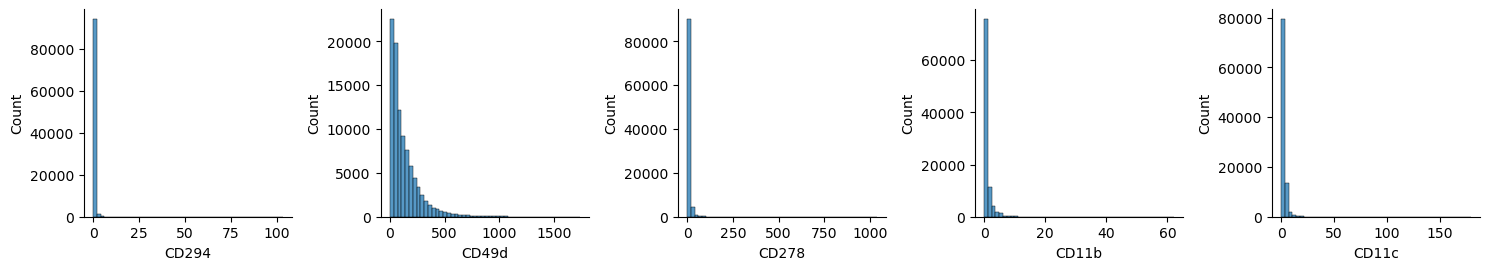

In [33]:
mu.pl.histogram(adt, adt.var_names[5:10], bins=50)

In [34]:
# calculate the distribution of the rna transcript in the raw data
mdata_raw["rna"].obs["log10umi"] = np.array(
    np.log10(mdata_raw["rna"].X.sum(axis=1) + 1)
).reshape(-1)

/tmp/ipykernel_4797/3649591548.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mdata_raw['rna'].obs["log10umi"] = np.array(


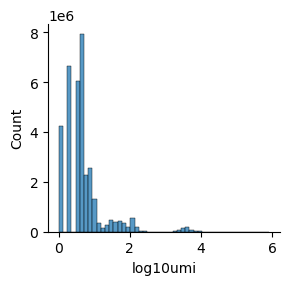

In [36]:
# plot the distribution of the rna umi threshold in the raw data
mu.pl.histogram(mdata_raw["rna"], ["log10umi"], bins=50)

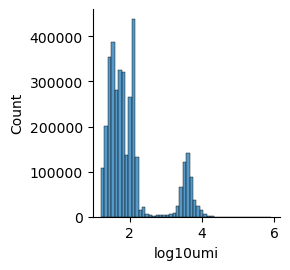

In [37]:
# zoom in certain region
mu.pl.histogram(
    mdata_raw["rna"][mdata_raw["rna"].obs.log10umi >= 1.2], ["log10umi"], bins=50
)

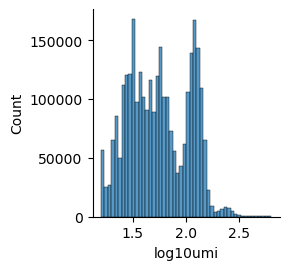

In [38]:
# plot the tentative threshold
mu.pl.histogram(
    mdata_raw["rna"][
        (mdata_raw["rna"].obs.log10umi >= 1.2) & (mdata_raw["rna"].obs.log10umi <= 2.8)
    ],
    ["log10umi"],
    bins=50,
)

In [39]:
# plot the distribution in the filtered cells
rna.obs["log10umi"] = np.array(np.log10(rna.X.sum(axis=1) + 1)).reshape(-1)

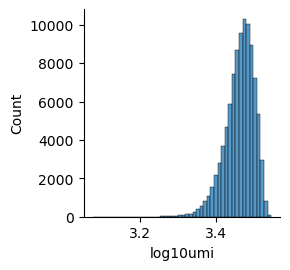

In [40]:
# in true cells, log 10 umi are above 3.2
mu.pl.histogram(rna, ["log10umi"], bins=50)

In [41]:
mdata_raw["prot"].var_names

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD294', 'CD49d', 'CD278',
       'CD11b', 'CD11c', 'CD127', 'CD16', 'CD172a', 'CD185', 'CD21', 'CD25',
       'CD27', 'CD279', 'CD304', 'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a',
       'CD86', 'TCR_Valpha7_2', 'CD103', 'CD57', 'CD69', 'CD192', 'CD45RA',
       'CD95', 'HLA_DR', 'KLRG1', 'CD137', 'CD161', 'CD183', 'CD85j', 'CX3CR1',
       'CD366', 'CD80', 'CD197', 'CD28', 'CD40', 'CD45RO', 'TCRab', 'TCRgd',
       'TIGIT', 'CD134', 'CD154', 'TCR_Valpha24_Jalpha18', 'CD24', 'CD319',
       'IgG1_K_Isotype_Control'],
      dtype='object')

In [42]:
# identify the isotype in the
isotypes = mdata_raw["prot"].var_names[
    mdata_raw["prot"].var_names.str.contains("Isotype")
]
isotypes

Index(['IgG1_K_Isotype_Control'], dtype='object')

In [ ]:
mdata_raw["prot"].X

In [ ]:
adt.var_names

In [ ]:
adt.var_names[adt.var_names.str.contains("Isotype")]

In [ ]:
mdata_raw["prot"].var_names[~mdata_raw["prot"].var_names.isin(adt.var_names)]

In [ ]:
adt.var_names[~adt.var_names.isin(mdata_raw["prot"].var_names)]

In [ ]:
mdata_raw["prot"].X

In [ ]:
adt.layers["counts"] = adt.X.copy()

In [ ]:
comb_mudata.update()

In [195]:
comb_mudata.write_h5mu(
    "/home/workspace/data/Ped_sen_teaseq_cd4tmem_cells_dsb_mudata.h5mu"
)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [ ]:
comb_mudata = mu.read_h5mu(
    "/home/workspace/data/Ped_sen_teaseq_cd4tmem_cells_dsb_mudata.h5mu"
)

In [43]:
comb_mudata

MuData object with n_obs × n_vars = 95941 × 37566
  4 modalities
    rna:	95941 x 36601
      obs:	'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'nCount_Tiles', 'nFeature_Tiles', 'percent_mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res_0_5', 'seurat_clusters', 'predicted_celltype_l1_score', 'predicted_celltype_l1', 'predicted_celltype_l2_score', 'predicted_celltype_l2', 'predicted_celltype_l3_score', 'predicted_celltype_l3', 'predicted_t_celltype_l1_score', 'predicted_t_celltype_l1', 'predicted_t_celltype_l2_score', 'predicted_t_celltype_l2', 'predicted_t_celltype_l3_score', 'predicted_t_celltype_l3', 'pediatric_senior', 'celltype_l0', 'predicted_labels', 'majority_voting', 'conf_score', 'over_clustering', 'predicted_score', 'predicted_labels_l2', 'predicted_score_l2', 'over_clustering_l2', 'majority_voting_l2', 'majority_percentage_l2', 'predicted_labels_l2_5', 'predicted_score_l2_5', 'over_clustering_l2_5', 'majority_voting_l2_5', 'majority_percentage_l2_5', 'final_labels', 'GEO_Accession', 'Batch', 'combined_sample_id', 'age', 'birth_year', 'tissue_type', 'library_type', 'race', 'Sex', 'subject_id', 'gating_celltype', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'barcodes', 'log10umi'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'NMF_neighbors_v1', 'batch_id_colors', 'dendrogram_leiden_NMF_0_5', 'dendrogram_leiden_NMF_1', 'final_labels_colors', 'gating_celltype_colors', 'hvg', 'leiden', 'leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'leiden_NMF_1', 'leiden_NMF_1_colors', 'log1p', 'majority_voting_colors', 'majority_voting_l2_5_colors', 'majority_voting_l3_colors', 'neighbors', 'over_clustering_colors', 'pca', 'pediatric_senior_colors', 'rank_genes_groups', 'subject_id_colors', 'umap'
      obsm:	'NMF_fac_v1', 'NMF_v1_X_umap', 'X_original_umap', 'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'logcounts', 'transform'
      obsp:	'NMF_neighbors_v1_connectivities', 'NMF_neighbors_v1_distances', 'connectivities', 'distances'
    adt:	95941 x 40
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.t_celltype.l1.score', 'predicted.t_celltype.l1', 'predicted.t_celltype.l2.score', 'predicted.t_celltype.l2', 'predicted.t_celltype.l3.score', 'predicted.t_celltype.l3', 'pediatric_senior', 'gating_celltype', 'CMV', 'subject_id', 'age_cmv', 'wsnn_res.0.5', 'nCount_clean_adt', 'nFeature_clean_adt', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'orginal_barcodes', 'well_id_barcodes'
      var:	'features', 'mean', 'std'
      uns:	'dendrogram_leiden_NMF_0_5', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_adt_harmony', 'X_nmfumap', 'X_pca'
      varm:	'ADT_HARMONY', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    tf:	95941 x 870
      obs:	'leiden_NMF_0_5'
      uns:	'dendrogram_leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'pca', 'rank_genes_groups'
      obsm:	'X_nmfumap', 'X_pca'
      varm:	'PCs'
    prot:	95941 x 55
   

In [44]:
# try in terminal
# run dsb normalization
pt.pp.dsb(
    comb_mudata,
    mdata_raw,
    empty_counts_range=(1.2, 2.8),
    isotype_controls=isotypes,
    add_layer=True,
    random_state=1,
)

/tmp/ipykernel_4797/934857360.py:3: DeprecationWarning: empty_counts_range will be deprecated in the future versions
  pt.pp.dsb(comb_mudata, mdata_raw,  empty_counts_range=(1.2, 2.8),


In [45]:
comb_mudata

MuData object with n_obs × n_vars = 95941 × 37566
  4 modalities
    rna:	95941 x 36601
      obs:	'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'nCount_Tiles', 'nFeature_Tiles', 'percent_mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res_0_5', 'seurat_clusters', 'predicted_celltype_l1_score', 'predicted_celltype_l1', 'predicted_celltype_l2_score', 'predicted_celltype_l2', 'predicted_celltype_l3_score', 'predicted_celltype_l3', 'predicted_t_celltype_l1_score', 'predicted_t_celltype_l1', 'predicted_t_celltype_l2_score', 'predicted_t_celltype_l2', 'predicted_t_celltype_l3_score', 'predicted_t_celltype_l3', 'pediatric_senior', 'celltype_l0', 'predicted_labels', 'majority_voting', 'conf_score', 'over_clustering', 'predicted_score', 'predicted_labels_l2', 'predicted_score_l2', 'over_clustering_l2', 'majority_voting_l2', 'majority_percentage_l2', 'predicted_labels_l2_5', 'predicted_score_l2_5', 'over_clustering_l2_5', 'majority_voting_l2_5', 'majority_percentage_l2_5', 'final_labels', 'GEO_Accession', 'Batch', 'combined_sample_id', 'age', 'birth_year', 'tissue_type', 'library_type', 'race', 'Sex', 'subject_id', 'gating_celltype', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'barcodes', 'log10umi'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'NMF_neighbors_v1', 'batch_id_colors', 'dendrogram_leiden_NMF_0_5', 'dendrogram_leiden_NMF_1', 'final_labels_colors', 'gating_celltype_colors', 'hvg', 'leiden', 'leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'leiden_NMF_1', 'leiden_NMF_1_colors', 'log1p', 'majority_voting_colors', 'majority_voting_l2_5_colors', 'majority_voting_l3_colors', 'neighbors', 'over_clustering_colors', 'pca', 'pediatric_senior_colors', 'rank_genes_groups', 'subject_id_colors', 'umap'
      obsm:	'NMF_fac_v1', 'NMF_v1_X_umap', 'X_original_umap', 'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'logcounts', 'transform'
      obsp:	'NMF_neighbors_v1_connectivities', 'NMF_neighbors_v1_distances', 'connectivities', 'distances'
    adt:	95941 x 40
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.t_celltype.l1.score', 'predicted.t_celltype.l1', 'predicted.t_celltype.l2.score', 'predicted.t_celltype.l2', 'predicted.t_celltype.l3.score', 'predicted.t_celltype.l3', 'pediatric_senior', 'gating_celltype', 'CMV', 'subject_id', 'age_cmv', 'wsnn_res.0.5', 'nCount_clean_adt', 'nFeature_clean_adt', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1', 'leiden_NMF_0_5', 'leiden_NMF_1', 'orginal_barcodes', 'well_id_barcodes'
      var:	'features', 'mean', 'std'
      uns:	'dendrogram_leiden_NMF_0_5', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_adt_harmony', 'X_nmfumap', 'X_pca'
      varm:	'ADT_HARMONY', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    tf:	95941 x 870
      obs:	'leiden_NMF_0_5'
      uns:	'dendrogram_leiden_NMF_0_5', 'leiden_NMF_0_5_colors', 'pca', 'rank_genes_groups'
      obsm:	'X_nmfumap', 'X_pca'
      varm:	'PCs'
    prot:	95941 x 55
   

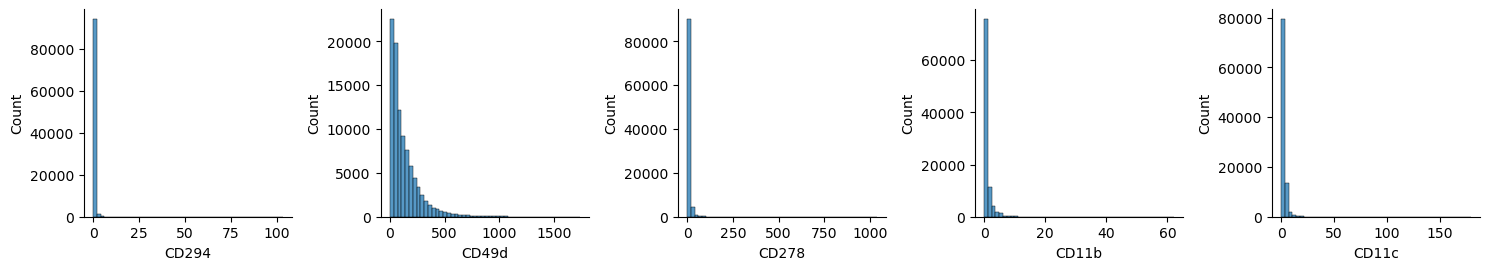

In [47]:
mu.pl.histogram(adt, adt.var_names[5:10], bins=50)

In [51]:
adt.var_names

Index(['CD152', 'CD194', 'CD196', 'CD244', 'CD26', 'CD294', 'CD49d', 'CD278',
       'CD11b', 'CD11c', 'CD127', 'CD16', 'CD172a', 'CD185', 'CD21', 'CD25',
       'CD27', 'CD279', 'CD304', 'CD38', 'CD39', 'CD4', 'CD56', 'CD71', 'CD8a',
       'CD86', 'TCR_Valpha7_2', 'CD103', 'CD57', 'CD69', 'CD192', 'CD45RA',
       'CD95', 'HLA_DR', 'KLRG1', 'CD137', 'CD161', 'CD183', 'CD85j', 'CX3CR1',
       'CD366', 'CD80', 'CD197', 'CD28', 'CD40', 'CD45RO', 'TCRab', 'TCRgd',
       'TIGIT', 'CD134', 'CD154', 'TCR_Valpha24_Jalpha18', 'CD24', 'CD319',
       'IgG1_K_Isotype_Control'],
      dtype='object')

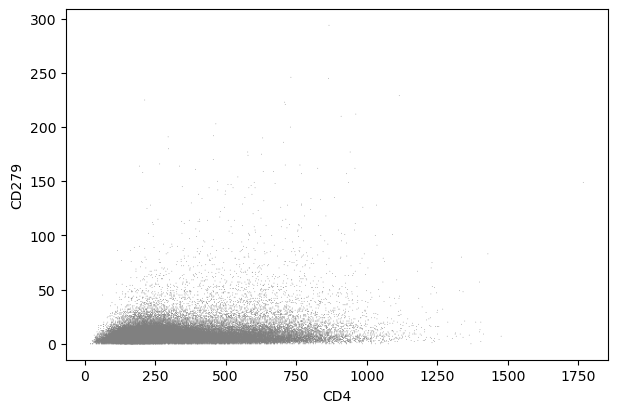

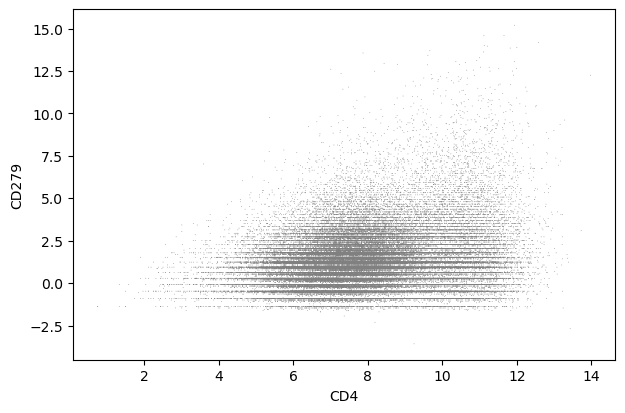

In [52]:
sc.pl.scatter(adt, x="CD4", y="CD279", layers="counts")
sc.pl.scatter(adt, x="CD4", y="CD279", layers="dsb")

In [54]:
adt.layers["counts"]

array([[ 12,  34, 496, ...,  31,   4,  10],
       [  6,  28, 559, ...,  60,   1,   5],
       [ 10,  36, 594, ...,  23,   4,   0],
       ...,
       [  0,  16,   9, ...,   0,   1,   0],
       [  2,  15,  11, ...,   2,   1,   0],
       [  1,  19,  19, ...,   1,   1,   0]])

In [57]:
# move dsb data into X slot
adt.X = adt.layers["dsb"].copy()

In [58]:
comb_mudata.update()

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [59]:
comb_mudata.write_h5mu(
    "/home/workspace/data/ped_sen_teaseq/Ped_sen_teaseq_cd4tmem_cells_dsb_mudata.h5mu"
)

/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/scanpy/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### upload file to hise

In [1]:
# import lib
import hisepy as hp

In [6]:
hp.upload.upload_files(
    files=[
        "/home/workspace/data/ped_sen_teaseq/Ped_sen_teaseq_cd4tmem_cells_dsb_mudata.h5mu"
    ],
    study_space_id="72ac97bb-a08c-4d89-8180-e4d057be2c70",
    title="Tfh17 Validatoin Ped_sen_teaseq mudata",
    input_file_ids=["c35e08c5-b04d-4b1d-8da8-4761b69aa082"],
    do_conda_build_check=False,
)

{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': 'aa405241-5d3d-4b14-9c95-44f28078f035',
 'ProcessId': '91bee1a8-d1fe-4cb2-a8e9-b2e09cab0823',
 'WorkflowId': '5fce403d-1d81-4ded-8dec-e52d06166dcc',
 'FileIds': ['eb70c5af-2430-4a40-adaa-a22b8a7791cd']}